# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import cupy as cp
import matplotlib.pyplot as plt
import time

In [5]:
#frank2d
from frank2d_gpu.frank2d_gpu import Frank2D
from frank2d_gpu.geometry import Geometry
from frank2d_gpu.fourier2d_gpu import FourierTransform2D
from frank2d_gpu.process_vis_gpu import Gridding
from frank2d_gpu.plot_gpu import Plot
from frank2d_gpu.constants import rad_to_arcsec, deg_to_rad
from frank2d_gpu.posterior_optimization_gpu import MAPEstimator

In [6]:

dir = "./../../data/"
data_file = dir + "SimulatedBlob.txt"
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

# Load data
file = cp.loadtxt(data_file, unpack=True)
u, v, Re, Im, Weights = file
Vis = Re + Im*1j
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

In [7]:
q = cp.hypot(uvtable['u'], uvtable['v'])
q_min = cp.min(q)
q_max = cp.max(q)

Rmax = 3*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 642
Rmax = 3


### frank2d

In [8]:
N_opt = [50]

In [9]:
maps = []
frank2d_objects = []
Qmaxs = []

In [10]:
times_opt =  [] # min
times_best = [] # seg

## Run

In [11]:
maps

[]

In [12]:

for i in N_opt:
    start_time = time.time()
    frank2d = Frank2D(N, Rmax)
    frank2d.process_vis(uvtable)
    initial_guess = {'m': -1, 'logl': 4, 'p':-1}
    frank2d.search_MAP(initial_guess= initial_guess, N = i)

    end_time = time.time()
    total_time = (end_time - start_time)/60
    print("     ---> N = {}, Time taken: {:.2f} mins".format(i, total_time))
    frank2d_objects.append(frank2d)
    times_opt.append(total_time)

    best = frank2d.MAP
    maps.append(best)
    print("     ---> MAP: "+ str(best))

    MAPEs = frank2d.MAPEstimator

    #print("     ---> Saving  frank2d object...")
    #import pickle
    #with open(dir+ disc+'_optCPU_Nopt{}.pkl'.format(i), 'wb') as f:
    #    pickle.dump(frank2d, f)

    GP =  MAPEs.GaussianModel
    DFT = GP.DFT2
    qmax = cp.max(DFT.Qmax)
    Qmaxs.append(qmax)

    print("     ---> Qmax: " + str(qmax))
    print("x-------------------------------------------------x")

===>  Setting gridded data...
Using existing visibility data...
Fitting the visibilities with Frank2D with 2DFT...
 + Time to preprocess the visibilities: 65.66 seconds
--> Calculating m_log_posterior with m, logc, logl: 0 -2.0 4.0
----------- m_log_post: -1015300988.6032606 -----------
Setting the initial guess...
 + Initial guess for the parameters (p, m, l): [-1.0, -1.0, 10000.0]
--> Calculating m_log_posterior with m, logc, logl: -1.0 4.0 4.0
----------- m_log_post: -1015300727.1926628 -----------
 + Initial guess for the parameters (p, m, l): [-2.0, -2.0, 10000.0]
--> Calculating m_log_posterior with m, logc, logl: -2.0 8.0 4.0
----------- m_log_post: -1015303604.3748908 -----------
Optimizing the posterior...
--> Calculating m_log_posterior with m, logc, logl: -2.0 8.0 4.0
----------- m_log_post: -1015303604.3748908 -----------
--> Calculating m_log_posterior with m, logc, logl: -2.0 8.1 4.0
----------- m_log_post: -1015303786.9453535 -----------
--> Calculating m_log_posterior w

In [13]:
print(N_opt)
print("Times taken: ", times_opt)
print("MAPs: ", maps)
print("Qmax: ", Qmaxs)

[50]
Times taken:  [23.690555850664776]
MAPs:  [{'m': -1.1178554759582104, 'c': 2113.7759647997, 'l': 56439.60464118096}]
Qmax:  [array(1215427.02681209)]


### Save

In [14]:
import pickle
dir_ = "../../data/exp/N_opt/"
for i in range(len(N_opt)):
    print("     ---> Saving  frank2d object...")
    #import pickle
    with open(dir_+'SimulatedBlob_optGPU_Nopt{}.pkl'.format(N_opt[i]), 'wb') as f:
        frank2d = frank2d_objects[i]
        pickle.dump(frank2d, f)

     ---> Saving  frank2d object...


## Upload objects

In [12]:
#upload the .pkl frank objects and inyect them in the array

import pickle

dir = "../../data/"

for i in N_opt:
    path = dir + 'SimulatedBlob_opt_Nopt' + str(i) + '.pkl'
    with open(path , 'rb') as f:   # 'rb' = read binary
        f2d = pickle.load(f)
        frank2d_objects.append(f2d)

In [13]:
for i in frank2d_objects:
    maps.append(i.MAP)
    Qmaxs.append(i.MAPEstimator.GaussianModel.DFT2.Qmax)

## Let's review the power spectrum

In [15]:
import numpy as np

In [16]:
# Plot visibilities gridded.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = u.get(), v.get()
Vis, Weights = Vis.get(), Weights.get()

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
x1 = binned_vis.uv
y1 = np.abs(binned_vis.V)**2
logx = np.log10(x1)
logy = np.log10(y1)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
x2 = binned_vis2.uv
y2 = np.abs(binned_vis2.V)**2
logx2 = np.log10(x2)
logy2 = np.log10(y2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)

def power_spectrum(x, m, c):
    return c*x**(m)

x = np.geomspace(np.sort(baselines)[1], baselines.max(), 1000)
lgx = np.log10(x)

y_fits = []
for i in range(len(N_opt)):
    y_fits.append(power_spectrum(x, maps[i]['m'], maps[i]['c']))

cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

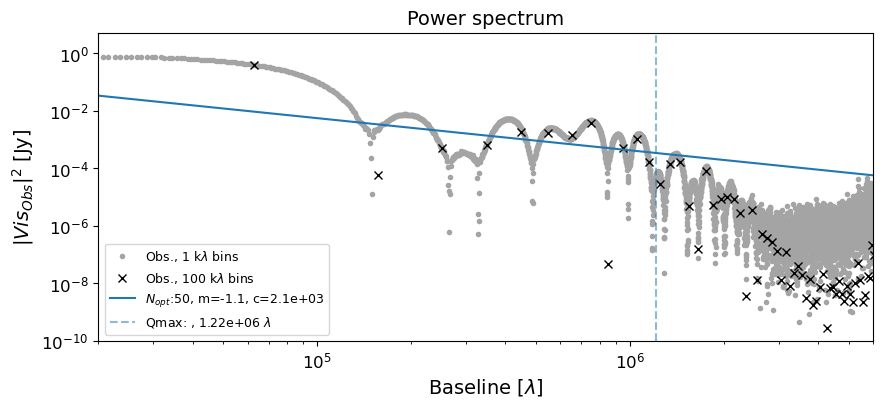

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(x1, y1, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(x2, y2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

for i in range(len(N_opt)):
    plt.plot(x, y_fits[i], label=r'$N_{opt}$:' + str(N_opt[i]) + ', m={:.1f}, c={:.1e}'.format(maps[i]['m'], maps[i]['c']), color='C{}'.format(i))
    plt.axvline(Qmaxs[i].get(), ls='--', color='C{}'.format(i), alpha=0.5, label=r'Qmax: '+ ', {:.2e} $\lambda$'.format(Qmaxs[i].get()))

plt.xlabel(r'Baseline [$\lambda$]', size = 14)
plt.ylabel(r'$|Vis_{Obs}|^{2}$ [Jy]', size = 14)
plt.xscale('log')
plt.yscale('log')
plt.legend(loc = 'best', fontsize = 9)
plt.title("Power spectrum", size = 14)
plt.tick_params(axis='both', labelsize=12)
plt.ylim(1e-10, 5)
plt.xlim(2e4, 6e6)
plt.show()

## Time related

### frank2d with best values

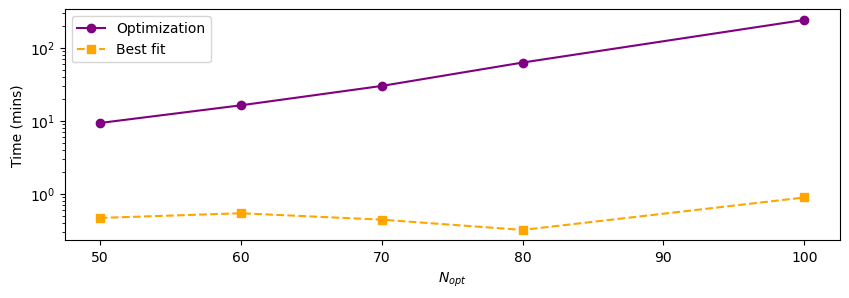

In [75]:
plt.figure(figsize=(10, 3))
plt.plot(N_opt, np.array(times_opt), 'o-', color='purple', label='Optimization')
plt.plot(N_opt, np.array(times_best)/60, 's--', color='orange', label='Best fit')
plt.xlabel(r'$N_{opt}$')
plt.ylabel("Time (mins)")
plt.yscale('log')
plt.legend()
plt.show()

In [14]:
maps

[{'m': -1.7118115146053943, 'c': 1107386.7020548182, 'l': 21833.50491835495},
 {'m': -1.7900507315194405, 'c': 4208615.485734088, 'l': 22746.607839035685},
 {'m': -2.205758019904303, 'c': 1360404752.1630862, 'l': 22817.1219726599},
 {'m': -2.9537030067142087, 'c': 40546491180778.625, 'l': 22781.422417760932},
 {'m': -3.7041542492704664,
  'c': 1.3882769163865464e+18,
  'l': 22906.177349190206}]

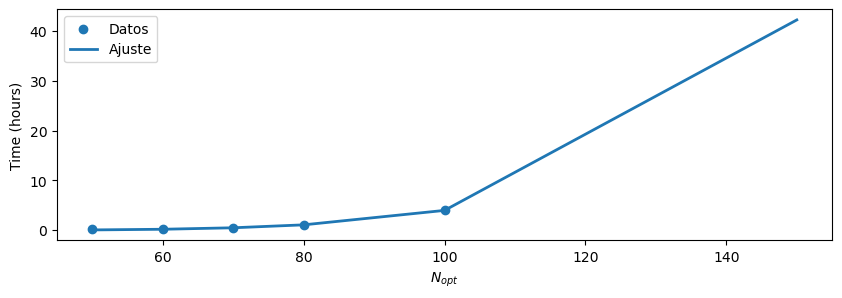

In [90]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

x , y = np.array([50, 60, 70, 80, 100]), np.array(times_opt)
x2 = np.array([50, 60, 70, 80, 100, 150])

# Modelo
def modelo(x, a, b):
    return b*x**a

# Ajuste
params, covariance = curve_fit(modelo, x, y)

a, b = params

# Graficar
plt.figure(figsize=(10, 3))
plt.scatter(x, y/60, label="Datos")
plt.plot(x2, modelo(x2, a, b)/60, label="Ajuste", linewidth=2)
plt.xlabel(r'$N_{opt}$')
plt.ylabel("Time (hours)")
plt.legend()
plt.show()

## Plot the stats for posterior

#### function to plot

In [48]:
def plot_MAP_estimation_results(results, results_best, N_opt, normalize = False):
    ms = results['ms']
    cs = results['cs']
    ls = results['ls']
    jDjs = results['jDjs']
    logdetDs = results['logdetDs']
    logdetSs = results['logdetSs']
    minus_log_posteriors = results['minus_log_posteriors']

    m_best = results_best['m']
    c_best = 10**results_best['logc']
    l_best = 10**results_best['logl']
    jDj_best = results_best['jDj']
    logdetD_best = results_best['logdetD']
    logdetS_best = results_best['logdetS']
    minus_log_posterior_best = results_best['minus_log_posterior']

    fig, axs = plt.subplots(3, 3, figsize=(10, 7))
    axs = axs.ravel()

    iterations = np.arange(1, len(ms) + 1)

    axs[0].plot(iterations, ms, '-', c='purple')
    axs[0].set_xlabel('Iteration')
    axs[0].axhline(  m_best, color='gray', linestyle='--',
                        label=r'$m_{best}$ =' + f'{m_best:.2e}')
    axs[0].set_ylabel('m')
    axs[0].legend(fontsize=10, loc='best')

    axs[1].plot(iterations, cs, '-', c='purple')
    axs[1].set_xlabel('Iteration')
    axs[1].axhline( c_best, color='gray', linestyle='--',
                       label=r'$c_{best}$ =' + f'{c_best:.2e}')
    axs[1].set_yscale('log')
    axs[1].set_ylabel('logc')
    axs[1].legend(fontsize=10, loc='best')

    axs[2].plot(iterations, ls, '-', c='purple')
    axs[2].set_xlabel('Iteration')
    axs[2].axhline(  l_best, color='gray', linestyle='--',
                         label=r'$l_{best}$ =' + f'{l_best:.2e}')
    axs[2].set_yscale('log')
    axs[2].set_ylabel('logl')
    axs[2].legend(fontsize=10, loc='best')

    if normalize:
        jDjs = np.abs(jDjs - jDj_best)
        axs[3].set_ylabel(r'$\|jDj- jDj_{best}\|$')
    else:
        axs[3].axhline( jDj_best, color='gray', linestyle='--',
                         label=r'$jDj_{best}$ =' + f'{jDj_best:.2e}')
        axs[3].set_ylabel('jDj')
        axs[3].legend(fontsize=10, loc='best')
    axs[3].set_xlabel('Iteration')
    axs[3].plot(iterations, jDjs, '-', c='red')

    #"""
    if normalize:
        logdetDs = np.abs(logdetDs - logdetD_best)
        axs[4].set_ylabel(r'$\|log|D| - log|D|_{best}\|$')
    else:
        axs[4].axhline(
            logdetD_best, color='gray', linestyle='--',
            label=r'$log|D|_{best}$ =' + f'{logdetD_best:.2e}')
        axs[4].legend(fontsize=10, loc='best')
        axs[4].set_ylabel('log|D|')
    axs[4].plot(iterations, logdetDs, '-', c='blue')
    axs[4].set_xlabel('Iteration')
    #"""

    if normalize:
        logdetSs = np.abs(logdetSs-logdetS_best)
        axs[5].set_ylabel(r'$\| log|S| - log|S|_{best}\|$')
    else:
        axs[5].axhline(  logdetS_best, color='gray', linestyle='--',
                         label=r'$log|S|_{best}$ =' + f'{logdetS_best:.2e}')
        axs[5].set_ylabel('log|S|')
        axs[5].legend(fontsize=10, loc='best')
    axs[5].plot(iterations, logdetSs, '-', c='green')
    axs[5].set_xlabel('Iteration')

    if normalize:
        minus_log_posteriors = np.abs(minus_log_posteriors - minus_log_posterior_best)
        axs[7].set_ylabel(r'$\|logP -logP_{best}\|$')
    else:
        axs[7].axhline(  minus_log_posterior_best, color='gray', linestyle='--',
                         label= r'$-logP_{best}$ =' + f'{minus_log_posterior_best:.2e}')
        axs[7].set_ylabel('-logP')
        axs[7].legend(fontsize=10, loc='best')
    axs[7].plot(iterations, minus_log_posteriors, '-', c='black')
    axs[7].set_xlabel('Iteration')

    for ax in [axs[6], axs[8]]:
        fig.delaxes(ax)
    
    for ax in [axs[3], axs[5], axs[7]]:
        ax.set_yscale('log')

    #for ax in [axs[3], axs[5], axs[7]]:
    #    ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))

    plt.suptitle(r'MAP Estimation $N_{opt}$ = '+ str(N_opt))
    plt.tight_layout()
    plt.show()

#### run them all

--> Calculating m_log_posterior with m, logc, logl: -2.172575106040783 9.347770064580128 4.848806225987972


----------- m_log_post: -1029042285.8640099 -----------
  + jDj: 2058104117.9676127
  + mu:  5135163714332.629
  + j:  0.07566820629998158


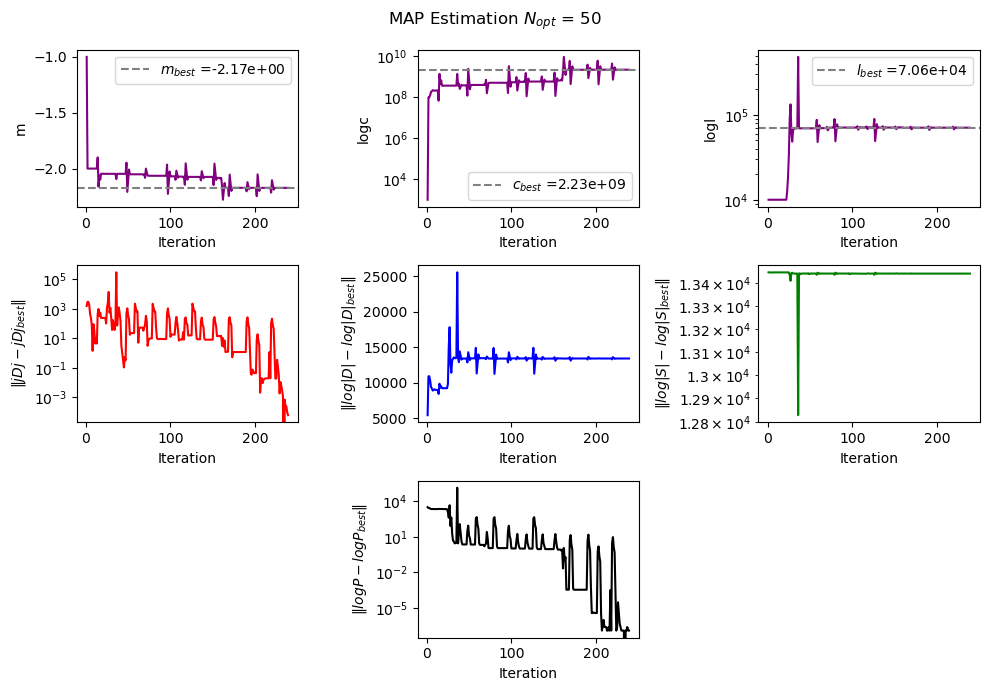

--> Calculating m_log_posterior with m, logc, logl: -2.6356759886206267 12.144946232059926 4.875562383800469
----------- m_log_post: -1017558655.0080854 -----------
  + jDj: 2035141514.657608
  + mu:  7239820664913.377
  + j:  0.07566964678384384


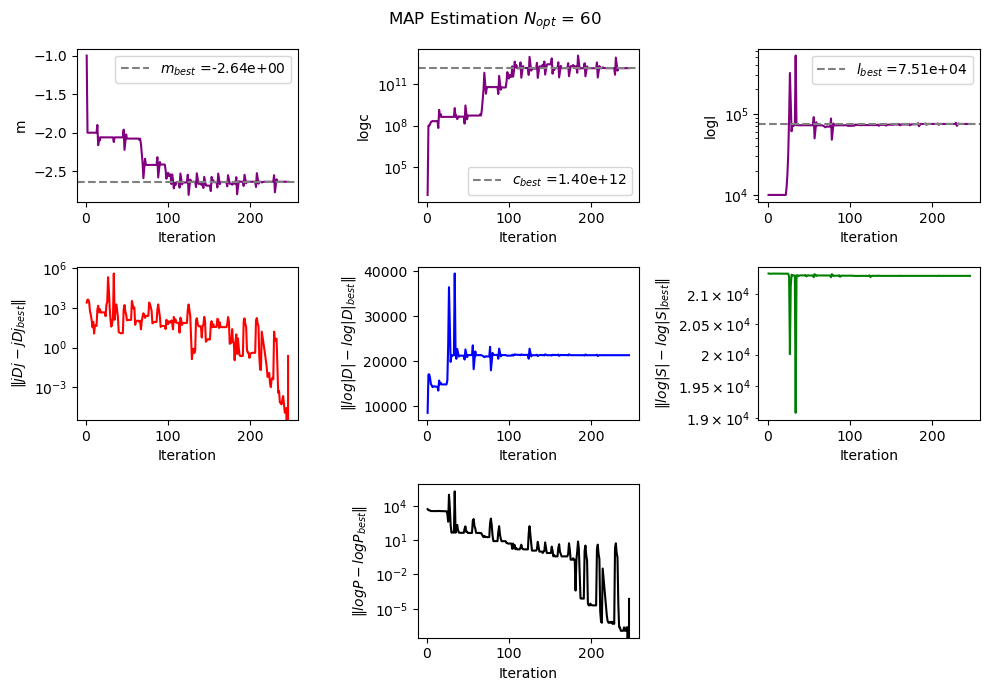

--> Calculating m_log_posterior with m, logc, logl: -2.96906055182971 14.085579939809001 4.851517201033795
----------- m_log_post: -1054773047.1993043 -----------
  + jDj: 2109574405.238204
  + mu:  10561523411703.406
  + j:  0.07567346416903448


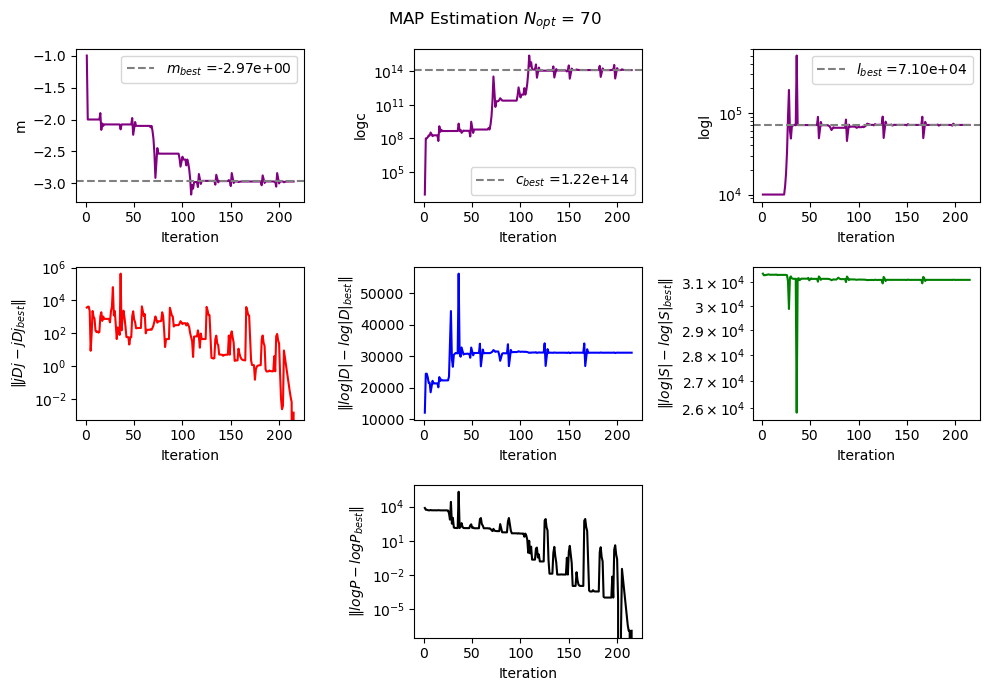

--> Calculating m_log_posterior with m, logc, logl: -3.446351239267294 16.96806297212158 4.835670736865331
----------- m_log_post: -1081101095.1876657 -----------
  + jDj: 2162233984.4284606
  + mu:  14235853577232.324
  + j:  0.07567169668816015


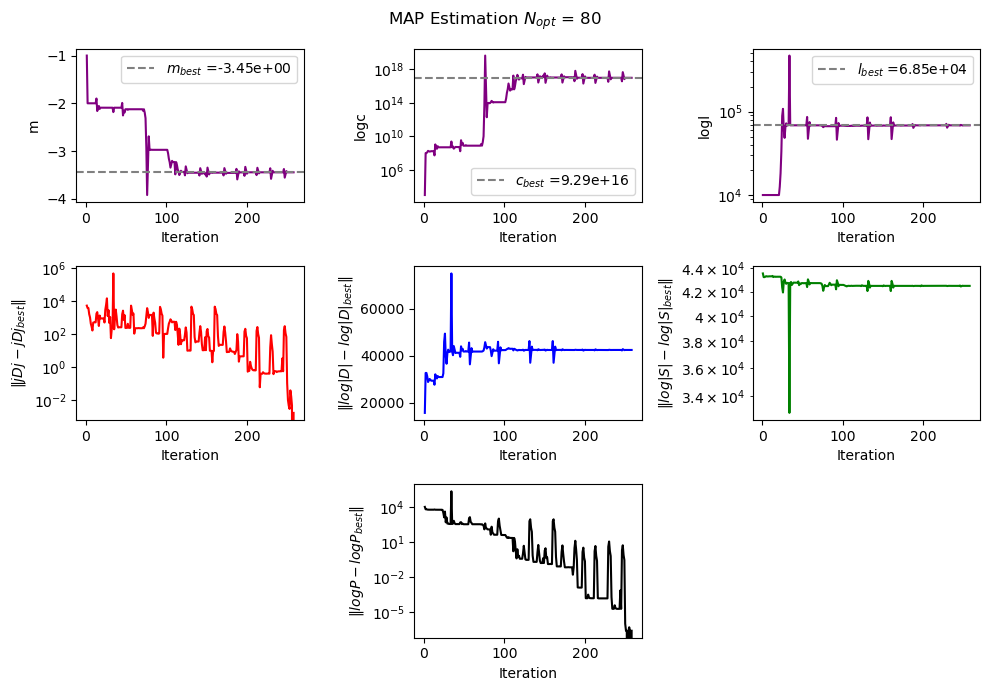

In [49]:
for i in range(0, len(N_opt)):
    frank2d_N = frank2d_objects[i]
    MAPEs_N = frank2d_N.MAPEstimator

    MAP_N = frank2d_N.MAP
    m_best_N = MAP_N['m']
    l_best_N = MAP_N['l']
    c_best_N = MAP_N['c']
    logl_best_N = np.log10(l_best_N)
    logc_best_N = np.log10(c_best_N)
    best_N = {
        'm': m_best_N,
        'logl': logl_best_N,
        'logc': logc_best_N
    }

    ms_N =  MAPEs_N._ms
    cs_N = MAPEs_N._cs
    ls_N = MAPEs_N._ls
    jDjs_N = MAPEs_N._jDjs
    logdetDs_N = MAPEs_N._logdetDs
    logdetSs_N = MAPEs_N._logdetSs
    minus_log_posteriors_N = MAPEs_N._minus_log_posteriors

    results_N = {
        'ms': ms_N,
        'cs': cs_N,
        'ls': ls_N,
        'jDjs': jDjs_N,
        'logdetDs': logdetDs_N,
        'logdetSs': logdetSs_N,
        'minus_log_posteriors': minus_log_posteriors_N,
    }

    GP_N =  MAPEs_N.GaussianModel
    p0, jDj0, logdetS0, logdetD0 = MAPEs_N._p0
    best_minus_log_posteriors_N = GP_N.minus_log_posterior(best_N) -p0
    best_jDj_N, best_logdetD_N, best_logdetS_N = GP_N._jDj - jDj0, GP_N._logdetD-logdetD0, GP_N._logdetS-logdetS0
    
    results_best_N = {
        'm': m_best_N,
        'logl': logl_best_N,
        'logc': logc_best_N,
        'minus_log_posterior': best_minus_log_posteriors_N,
        'jDj': best_jDj_N,
        'logdetD': best_logdetD_N,
        'logdetS': best_logdetS_N,
    }

    plot_MAP_estimation_results(results_N, results_best_N, N_opt[i], normalize = True) 


### Maximum baseline for each N_opt

In [55]:
for i in range(0, len(N_opt)):
    frank2d_N = frank2d_objects[i]
    MAPEs_N = frank2d_N.MAPEstimator
    GP_N =  MAPEs_N.GaussianModel
    DFT_N = GP_N._2DFT
    print( DFT_N.Qmax)


1823140.5402181398
2187768.648261768
2552396.756305396
2917024.8643490244
3646281.0804362795


In [26]:
l_array = []
for i in maps:
    l_array.append(i['l'])

In [34]:
mis_colores = ['C0', 'C1', 'C2', 'C3']

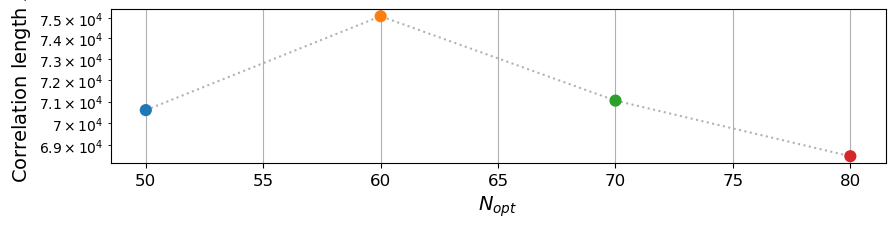

In [63]:
plt.figure(figsize=(10,2))

plt.plot(N_opt, l_array, ':', color='black', alpha=0.3, zorder=1)
plt.scatter(N_opt, l_array, c=mis_colores, s=60, zorder=2)
plt.yscale('log')
plt.xlabel(r'$N_{opt}$', size=14)
plt.ylabel(r'Correlation length $\ell$', size=14)
plt.tick_params(axis='both', labelsize=12)
plt.grid()
plt.show()


In [65]:
p = -1
m = -1
logc = p - 5*m


SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (2249569240.py, line 1)

## Plot the best

In [39]:
times_best2 = []

In [40]:
frank2d_objects_best = []

In [41]:
for i in range(len(frank2d_objects)):
    start = time.time()
    frank2d = Frank2D(N, Rmax)
    maps_i = maps[i]
    frank2d.fit(data = uvtable, kernel_params = maps_i, rtol = 1e-10)

    end = time.time()
    total_time = end - start
    times_best2.append(total_time)
    frank2d_objects_best.append(frank2d)
    print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with maps ={maps_i} took {end - start} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")


===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.172575106040783, 'c': 2227255625.75811, 'l': 70600.24789788261}
===>  Creating sparse linear system...
        + time kernel = 0.01  min |  0.67 seconds
        + Using preconditioner method:  jacobi
        + time building system = 0.01  min |  0.84 seconds
===>  Solving linear system...
         + maxiter =  50000  & rtol =  1e-10
         + final tolerance :  0.0


         + Fitting with BiCGStab...:   0%|          | 199/50000 [00:10<44:53, 18.49 iterations/s]


            --> times solving system = 0.18  min |  11.09 seconds
          + CGM converged?   True
          + Fit correctly?    ✔✔✔✔✔✔✔ CGM Sucess..
Building full visibility model...
--> times building full visibility model = 0.02  min |  1.10 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with maps ={'m': -2.172575106040783, 'c': 2227255625.75811, 'l': 70600.24789788261} took 13.53720736503601 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.6356759886206267, 'c': 1396195494012.863, 'l': 75086.59037624154}
===>  Creating sparse linear system...
        + time kernel = 0.01  min |  0.61 seconds
        + Using preconditioner method:  jacobi
        + time building system = 0.01  min |  0.61 seconds
===>  Solving linear system...
         + maxiter =  50000  & rtol =  1e-10
         + final tolerance :  0.0


         + Fitting with BiCGStab...:   1%|          | 261/50000 [00:13<44:22, 18.68 iterations/s]


            --> times solving system = 0.23  min |  13.97 seconds
          + CGM converged?   True
          + Fit correctly?    ✔✔✔✔✔✔✔ CGM Sucess..
Building full visibility model...
--> times building full visibility model = 0.02  min |  1.13 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with maps ={'m': -2.6356759886206267, 'c': 1396195494012.863, 'l': 75086.59037624154} took 16.091917991638184 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.96906055182971, 'c': 121781113253450.83, 'l': 71042.33070708397}
===>  Creating sparse linear system...
        + time kernel = 0.01  min |  0.55 seconds
        + Using preconditioner method:  jacobi
        + time building system = 0.01  min |  0.55 seconds
===>  Solving linear system...
         + maxiter =  50000  & rtol =  1e-10
         + final tolerance :  0.0


         + Fitting with BiCGStab...:   1%|          | 283/50000 [00:15<46:01, 18.01 iterations/s]


            --> times solving system = 0.26  min |  15.73 seconds
          + CGM converged?   True
          + Fit correctly?    ✔✔✔✔✔✔✔ CGM Sucess..
Building full visibility model...
--> times building full visibility model = 0.02  min |  1.12 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with maps ={'m': -2.96906055182971, 'c': 121781113253450.83, 'l': 71042.33070708397} took 17.77356481552124 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -3.446351239267294, 'c': 9.29101095435081e+16, 'l': 68496.87161364655}
===>  Creating sparse linear system...
        + time kernel = 0.01  min |  0.53 seconds
        + Using preconditioner method:  jacobi
        + time building system = 0.01  min |  0.53 seconds
===>  Solving linear system...
         + maxiter =  50000  & rtol =  1e-10
         + final tolerance :  0.0


         + Fitting with BiCGStab...:   1%|          | 370/50000 [00:20<46:38, 17.73 iterations/s]


            --> times solving system = 0.35  min |  20.87 seconds
          + CGM converged?   True
          + Fit correctly?    ✔✔✔✔✔✔✔ CGM Sucess..
Building full visibility model...
--> times building full visibility model = 0.03  min |  1.71 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with maps ={'m': -3.446351239267294, 'c': 9.29101095435081e+16, 'l': 68496.87161364655} took 23.519453525543213 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [50]:
for i in range(len(frank2d_objects_best)):
    Plot_ = Plot(frank2d_objects_best[i], geom)
    Plot_.intensity( vmax=5e10,  gamma = 1, zoom=2,
                     title= r'$I_{model}^{frank2d}$ for $N_{opt}$ = ' + str(N_opt[i]))
    Plot_.visibility(fig_size = 6, zoom =2,
                     title = r'$Vis_{model}^{frank2d}$ for $N_{opt}$ = ' + str(N_opt[i]))

TypeError: Plot.intensity() got an unexpected keyword argument 'size_label'

## Review power spectrum

In [ ]:
params_N50, params_N60, params_N70, params_N80, params_N100 = [{'m': -2.692877726304575, 'c': 5565999406071.04, 'l': 85344.27916739318}, {'m': -3.173339346404725, 'c': 4782311642990891.0, 'l': 83515.6290880256}, {'m': -3.5831562281230305, 'c': 1.473704358376612e+18, 'l': 81079.44744259916}, {'m': -4.572442130254884, 'c': 1.0084384650978846e+24, 'l': 68720.771036978}, {'m': -6.0445769086881205, 'c': 1.4300593860064604e+33, 'l': 80200.56804261949}]
Qmax_N50, Qmax_N60, Qmax_N70, Qmax_N80, Qmax_N100 = [1823140.5402181398, 2187768.648261768, 2552396.756305396, 2917024.8643490244, 3646281.0804362795]

# Plot visibilities gridded.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
x1 = binned_vis.uv
y1 = np.abs(binned_vis.V)**2
logx = np.log10(x1)
logy = np.log10(y1)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
x2 = binned_vis2.uv
y2 = np.abs(binned_vis2.V)**2
logx2 = np.log10(x2)
logy2 = np.log10(y2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)

def power_spectrum(x, m, c):
    return c*x**(m)

x = np.geomspace(np.sort(baselines)[1], baselines.max(), 1000)
lgx = np.log10(x)

y_N50 = power_spectrum(x, params_N50['m'], params_N50['c'])
y_N60 = power_spectrum(x, params_N60['m'], params_N60['c'])
y_N70 = power_spectrum(x, params_N70['m'], params_N70['c'])
y_N80 = power_spectrum(x, params_N80['m'], params_N80['c'])
y_N100 = power_spectrum(x, params_N100['m'], params_N100['c'])

cs, ms = ['#a4a4a4', 'k'], ['.', 'x']


In [ ]:

plt.figure(figsize=(10, 3))
plt.plot(x1, y1, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(x2, y2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

plt.plot(x, y_N50, c = 'r', label=r'$N_{opt}$=50,'+ 'm={:.1f}, c={:.1e}'.format(params_N50['m'], params_N50['c']))
plt.plot(x, y_N60, c = 'orange', label=r'$N_{opt}$=60,'+ 'm={:.1f}, c={:.1e}'.format(params_N60['m'], params_N60['c']))
plt.plot(x, y_N70, c='g', label=r'$N_{opt}$=70,'+ ' m={:.1f}, c={:.1e}'.format(params_N70['m'], params_N70['c']))
plt.plot(x, y_N80, c='b', label=r'$N_{opt}$=80,'+ ' m={:.1f}, c={:.1e}'.format(params_N80['m'], params_N80['c']))
plt.plot(x, y_N100, c='purple', label=r'$N_{opt}$=100,'+ ' m={:.1f}, c={:.1e}'.format(params_N100['m'], params_N100['c']))

plt.axvline(Qmax_N50, color='r', ls=':', label=r'$Q_{max}$ $N_{opt}$=50')
plt.axvline(Qmax_N60, color='orange', ls=':')
plt.axvline(Qmax_N70, color='g', ls=':')
plt.axvline(Qmax_N80, color='b', ls=':')
plt.axvline(Qmax_N100, color='purple', ls=':')

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|^{2}$ [Jy]', size = 10)
plt.xscale('log')
plt.yscale('log')
plt.legend(loc = 'best', fontsize = 6)
plt.title("Power spectrum")
plt.ylim(1e-12, 2)
plt.xlim(2e4, 6e6)
plt.show()